In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.transforms as transforms
import matplotlib.ticker as ticker
from matplotlib.colors import LogNorm
from matplotlib.colors import SymLogNorm
import yt
import os
from dotenv import dotenv_values
import glob
import pandas as pd
import re
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from scipy.stats import linregress


In [32]:
def read_in_spectrum_data(run_dir):
    spect_dir = os.path.join(run_dir, "turb_vel*.txt")
    files = sorted(glob.glob(spect_dir))
    dfs = []
    for f in files:
        num = int(re.search(r'turb_vel(\d+)\.txt', f).group(1))
        df = pd.read_csv(f, sep='\s+', header=None)
        df['file_num'] = num
        dfs.append(df)
    
    spect_data = pd.concat(dfs, ignore_index=True)
    return spect_data
    
spect_data_list = []
N_seeds = 1
for i in range(N_seeds):
    run_dir_i = f"Kolmogorov_WENO_2048_mu_1em4_cell_depth_1p6em4_F_0_1em1_n_WN_3_dt_9em5_seed_{i+1}00"
    # run_dir_i = f"Kolmogorov_WENO_512_512_mu_1em4_cell_depth_7em6_F_0_1p49em1_n_WN_35_dt_3em5_seed_{i+1}00"
    # run_dir_i = f"Kolmogorov_WENO_512_512_mu_1em4_cell_depth_7em6_F_0_2em1_n_WN_35_dt_3em5_seed_{i+1}00"
    spect_data_i = read_in_spectrum_data(run_dir_i)
    spect_data_list.append(spect_data_i)


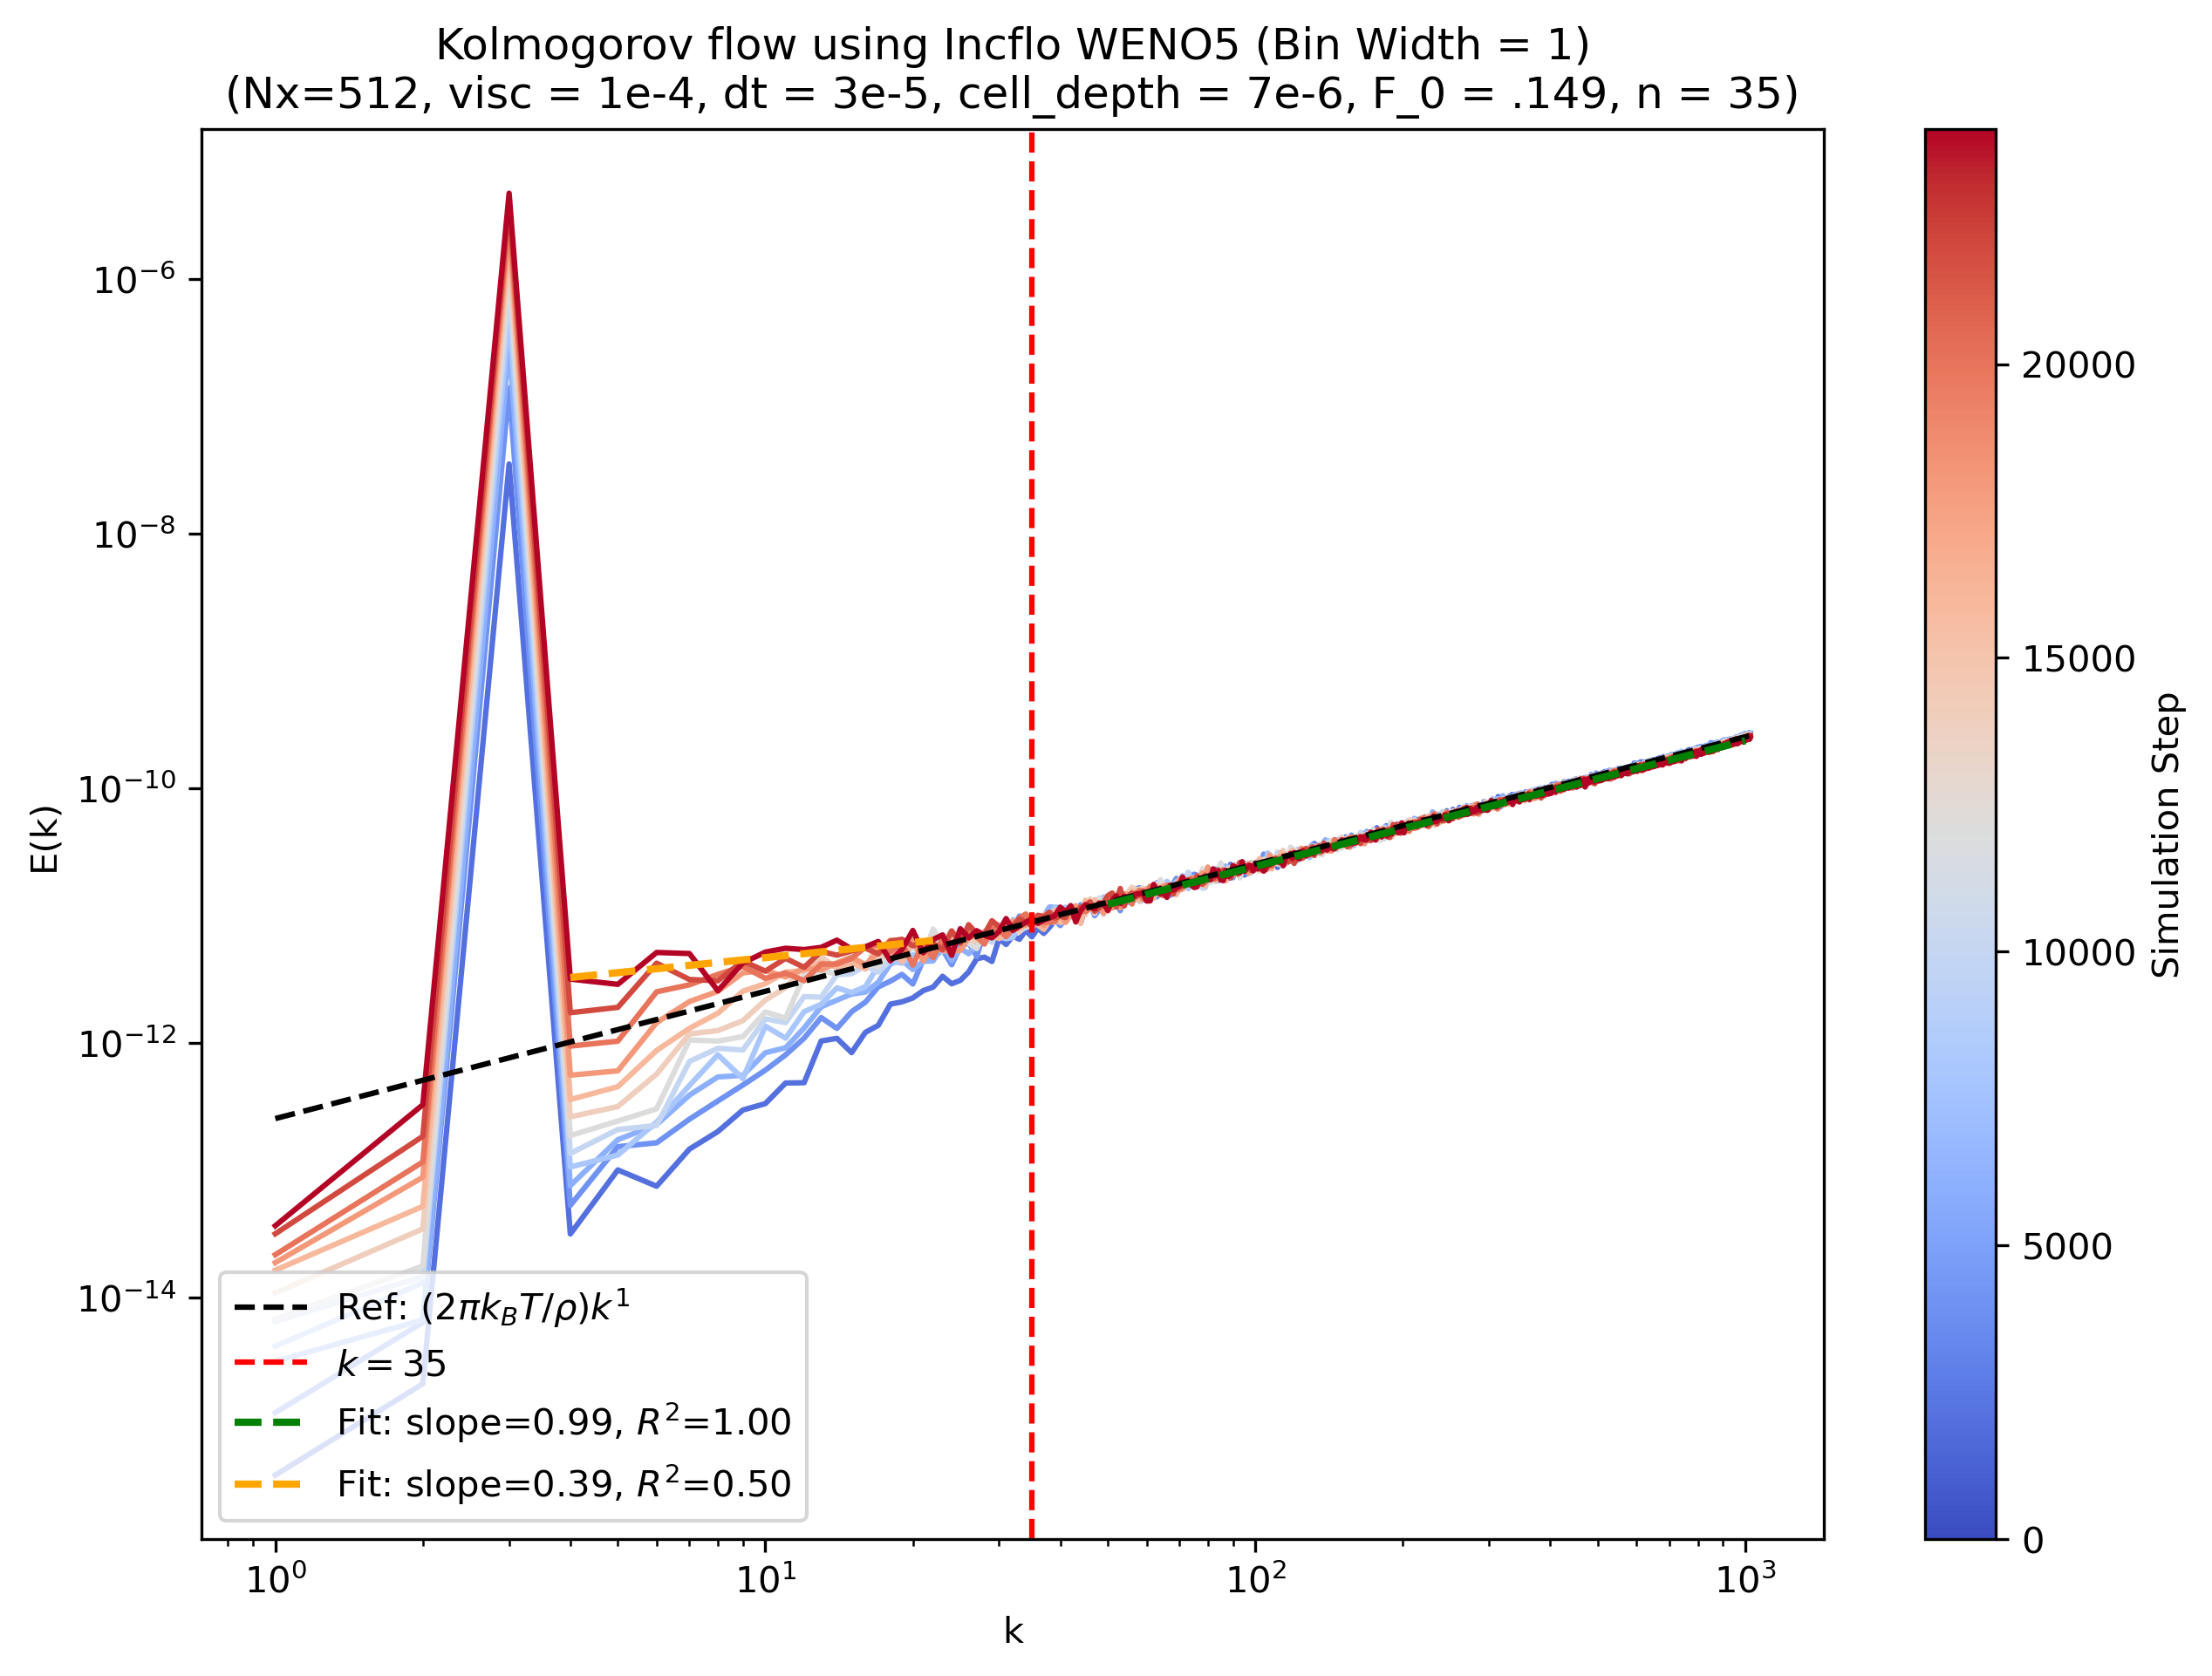

In [33]:
def add_power_law_fit(ax, k_vals, E_vals, k_min, k_max, color):
    """Fits E(k) = c * k^p, calculates R^2, and plots the fit."""
    mask = (k_vals >= k_min) & (k_vals <= k_max)
    k_fit, E_fit = k_vals[mask], E_vals[mask]
    
    if len(k_fit) < 2: return
    
    # Linear regression in log-log space
    log_k, log_E = np.log10(k_fit), np.log10(E_fit)
    slope, intercept, r_value, _, _ = linregress(log_k, log_E)
    r_squared = r_value**2
    
    # Plot the fit line
    fit_line = (10**intercept) * (k_fit**slope)
    label = f'Fit: slope={slope:.2f}, $R^2$={r_squared:.2f}'
    ax.plot(k_fit, fit_line, color=color, linestyle='--', linewidth=2, label=label)

# physical_wavenumber = True
physical_wavenumber = False

kB = 1.380649e-16
T = 294.0
rho = 1
# Nx = 512
cell_depth = 1e-5
k_min_g = 50
k_max_g = 1000

k_min_o = 4
k_max_o = 22

fig, ax = plt.subplots(figsize=(10, 7), dpi=300)
file_nums = sorted(spect_data_list[0]['file_num'].unique())
norm = mcolors.Normalize(vmin=min(file_nums), vmax=max(file_nums))
cmap = cm.coolwarm

bin_width = 1
for num, group in spect_data_list[0].groupby('file_num'):
    # if num > 1000:
    #     continue
    raw_k, raw_E = group[0].values, group[1].values
    
    num_bins = len(raw_k) // bin_width
    k_binned = raw_k[:num_bins*bin_width].reshape(-1, bin_width).mean(axis=1)
    if physical_wavenumber:
        k_binned = 2 * np.pi * k_binned
    E_binned = raw_E[:num_bins*bin_width].reshape(-1, bin_width).mean(axis=1)
    
    ax.plot(k_binned, E_binned, color=cmap(norm(num)))
    # if num < 100:
        # print(f"k_binned: {k_binned}")
    
    # if num == target_time:
    fit_k, fit_E = k_binned, E_binned

ax.set_xscale('log')
ax.set_yscale('log')

# --- Add Reference Lines ---
# FDT = (2 * np.pi * kB * T) / (rho)
FDT = (kB * T) / (rho)
# ax.plot(fit_k, 2e-13 * fit_k, 'k--', label=r'Ref: $k^{1}$') 
if physical_wavenumber:
    ax.plot(fit_k, FDT * fit_k, 'k--', label=r'Ref: $(k_B T / \rho) k^{1}$') 
else:
    ax.plot(fit_k, 2 * np.pi * FDT * fit_k, 'k--', label=r'Ref: $(2 \pi k_B T / \rho) k^{1}$') 
# ax.plot(fit_k[:25], 1e-4 * np.power(fit_k[:25].astype(float), -4), 'm--', label=r'Ref: $k^{-4}$')

if physical_wavenumber:
    ax.axvline(x = 2 * np.pi, color = "red", linestyle = "--", label=r"$k=2\pi$")
    ax.set_xlabel(r'$2 \pi k$')
else:
    ax.axvline(x = 35, color = "red", linestyle = "--", label=r"$k=35$")
    ax.set_xlabel('k')
# # 1024:
# # add_power_law_fit(ax, fit_k, fit_E, k_min=1.0, k_max= 60.0, color='gray')
# add_power_law_fit(ax, fit_k, fit_E, k_min=1.0, k_max=20.0, color='blue')
# # add_power_law_fit(ax, fit_k, fit_E, k_min=60.0, k_max=512.0, color='orange')
# # add_power_law_fit(ax, fit_k, fit_E, k_min=60.0, k_max=220.0, color='green')

# 512
# add_power_law_fit(ax, fit_k, fit_E, k_min=1.0, k_max= 30.0, color='gray')
# add_power_law_fit(ax, fit_k, fit_E, k_min=1.0, k_max=8.0, color='blue')
# add_power_law_fit(ax, fit_k, fit_E, k_min=4.0, k_max=255.0, color='orange')
if physical_wavenumber:
    add_power_law_fit(ax, fit_k, fit_E, k_min=2 * np.pi * k_min_g, k_max=2 * np.pi * k_max_g, color='green')
else:
    add_power_law_fit(ax, fit_k, fit_E, k_min=k_min_g, k_max=k_max_g, color='green')
    add_power_law_fit(ax, fit_k, fit_E, k_min=k_min_o, k_max=k_max_o, color='orange')


# 2048:
# add_power_law_fit(ax, fit_k, fit_E, k_min=1.0, k_max= 50.0, color='gray')
# add_power_law_fit(ax, fit_k, fit_E, k_min=1.0, k_max=13.0, color='blue')
# add_power_law_fit(ax, fit_k, fit_E, k_min=100.0, k_max=1024.0, color='orange')
# add_power_law_fit(ax, fit_k, fit_E, k_min=100.0, k_max=400.0, color='green')

ax.set_ylabel('E(k)')

# Legend for the fits and reference lines
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[-4:], labels[-4:], loc='lower left')

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
fig.colorbar(sm, ax=ax, label='Simulation Step')

# plt.title(f"Incflo WENO5 Kolmogorov Energy Spectrum (Bin Width = {bin_width})\n(Nx=1024, visc = 1e-4, dt = 1.6e-4, cell_depth = 4e-5, ts = false)")
plt.title(f"Kolmogorov flow using Incflo WENO5 (Bin Width = {bin_width})\n(Nx=512, visc = 1e-4, dt = 3e-5, cell_depth = 7e-6, F_0 = .149, n = 35)")
# plt.title(f"Kolmogorov flow using Incflo WENO5 (Bin Width = {bin_width})\n(Nx=512, visc = 1e-4, dt = 3e-5, cell_depth = 7e-6, F_0 = .2, n = 35)")
# plt.title(f"Kolmogorov using Incflo WENO5 (Bin Width = {bin_width})\n(Nx=2048, visc = 1e-4, dt = 9e-5, cell_depth = 1.6e-4, ts = false)")
plt.show()

In [34]:
kB = 1.380649e-16
T = 294.0
rho = 1
cell_depth = 1e-5
FDT = (kB * T) / (rho)
FDT * (2 * np.pi)

2.5504128122846233e-13

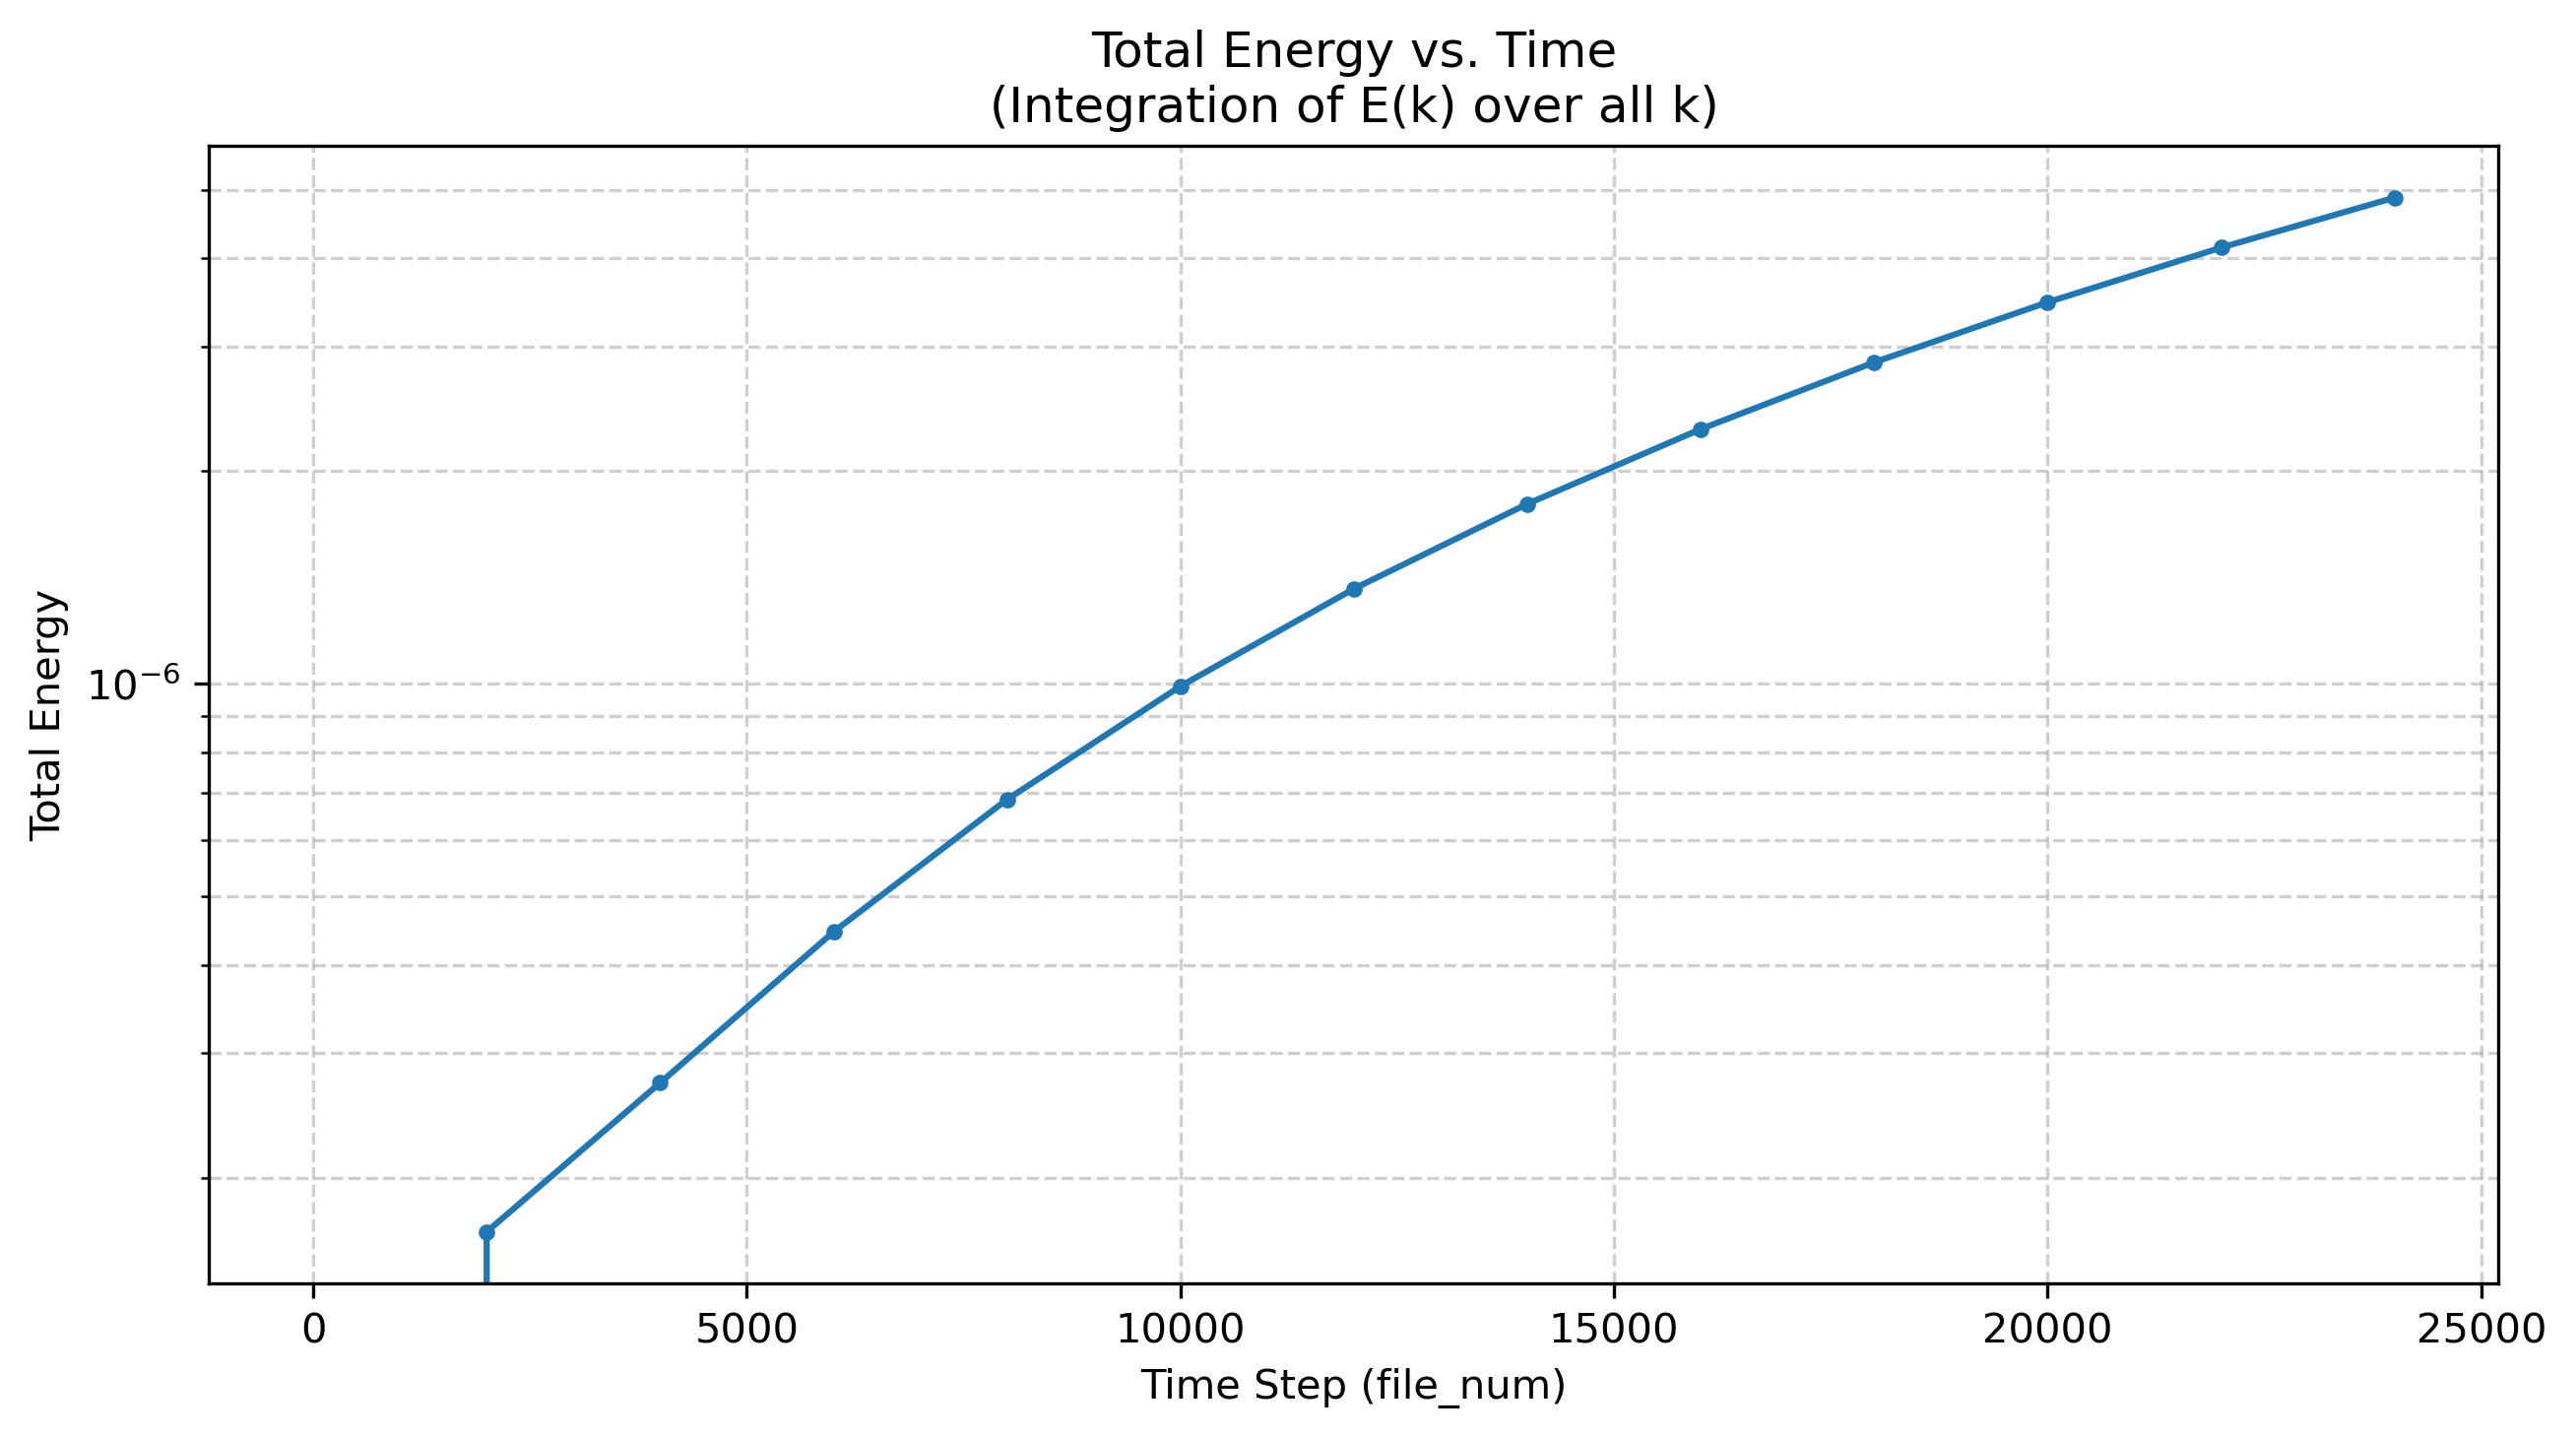

In [35]:
# Lists to store the time steps and their corresponding total energies
time_steps = []
total_energies = []

# Loop through each time step (file_num) to integrate the spectrum
for num, group in spect_data_list[0].groupby('file_num'):
    # print(f"num: {num}")
    raw_k = group[0].values
    raw_E = group[1].values
    
    # Scale k if using physical wavenumbers
    if physical_wavenumber:
        k_vals = 2 * np.pi * raw_k
    else:
        k_vals = raw_k
        
    # Calculate the spacing between adjacent k values
    dk = np.diff(k_vals)
    # Calculate the average E(k) between adjacent points
    E_avg = (raw_E[:-1] + raw_E[1:]) / 2.0
    # if num == 200:
    #     print(f"raw_E: {raw_E}")
    #     print(f"E_avg: {E_avg}")
    # Sum the area of all trapezoids
    E_tot = np.sum(E_avg * dk)
    
    time_steps.append(num)
    total_energies.append(E_tot)

# Plot the total energy as a function of time
fig, ax = plt.subplots(figsize=(10, 5), dpi=300)

ax.plot(time_steps, total_energies, marker='o', markersize=3, linestyle='-')

ax.set_xlabel('Time Step (file_num)')
ax.set_ylabel('Total Energy')
ax.set_title('Total Energy vs. Time\n(Integration of E(k) over all k)')

ax.set_yscale('log')

ax.grid(True, which='both', linestyle='--', alpha=0.6)

plt.show()

In [45]:
def read_in_plt_data(run_dir):
    plt_dir = os.path.join(run_dir, "plt*")
    files = sorted(glob.glob(plt_dir))
    print(f"Found {len(files)} plotfiles in {run_dir}.")

    plt_data = yt.DatasetSeries(files)
    
    
    return plt_data, len(files)

plt_data_list = []
N_plt_list = []
N_seeds = 1
for i in range(N_seeds):
    run_dir_i = f"Kolmogorov_WENO_2048_mu_1em4_cell_depth_1p6em4_F_0_1em1_n_WN_3_dt_9em5_seed_{i+1}00"
    
    plt_data_i, N_plt_i = read_in_plt_data(run_dir_i)
    plt_data_list.append(plt_data_i)
    N_plt_list.append(N_plt_i)

Found 13 plotfiles in Kolmogorov_WENO_2048_mu_1em4_cell_depth_1p6em4_F_0_1em1_n_WN_3_dt_9em5_seed_100.


In [49]:
Nx, Ny = 2048, 2048

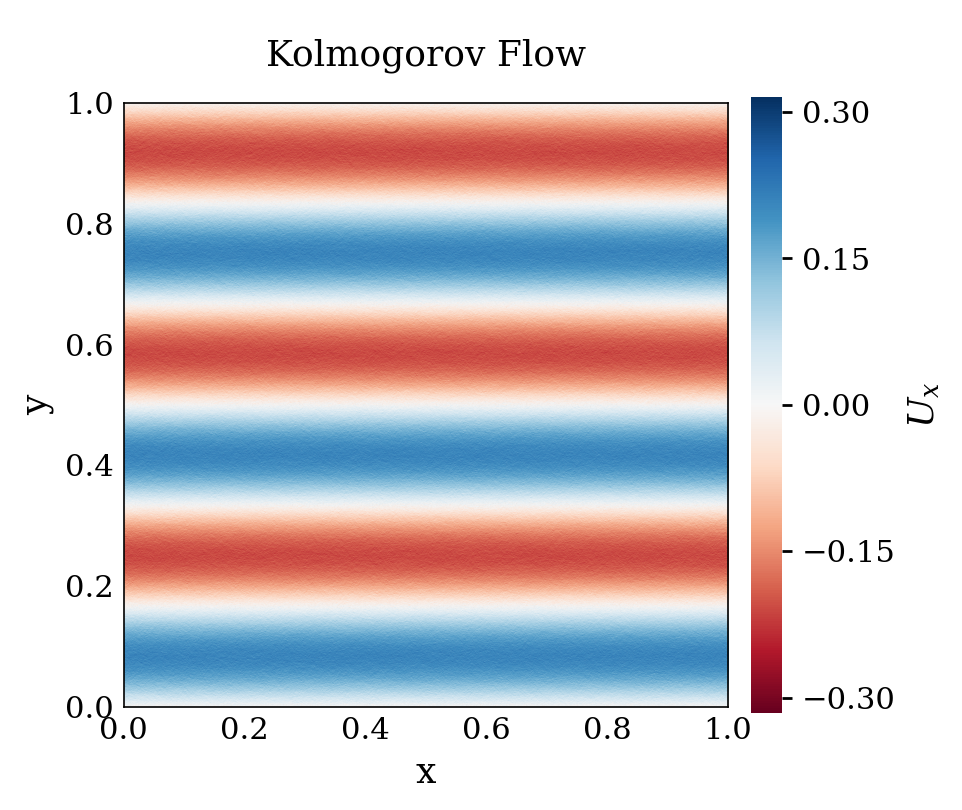

In [55]:
def frame_plot_helper(ax, data, title, legend_label=None, cmap='RdBu', clim=None, use_log=False, fontsize=13, Lx=1, Ly=1, cbar_loc='top'):
    """Plot data with colorbar on top in separated axes"""
    
    # Define bounding boxes based on the requested colorbar location
    if cbar_loc == 'right':
        plot_height, plot_bottom = 0.80, 0.10
        plot_width, plot_left = 0.78, 0.05
        cbar_height, cbar_bottom = 0.80, 0.10
        cbar_width, cbar_left = 0.04, 0.86
        
        pbbox = transforms.Bbox.from_bounds(plot_left, plot_bottom, plot_width, plot_height)
        cbbox = transforms.Bbox.from_bounds(cbar_left, cbar_bottom, cbar_width, cbar_height)
        
        # sm = cm.ScalarMappable(cmap=cmap, norm=norm)
        # fig.colorbar(sm, ax=ax, label='Simulation Step')
    else: # Default to 'top'
        plot_height, plot_bottom = 0.75, 0.05
        plot_width, plot_left = 0.90, 0.075  
        cbar_height, cbar_bottom = 0.04, 0.85
        
        pbbox = transforms.Bbox.from_bounds(plot_left, plot_bottom, plot_width, plot_height)
        cbbox = transforms.Bbox.from_bounds(plot_left, cbar_bottom, plot_width, cbar_height)
    
    to_axes_bbox = transforms.BboxTransformTo(ax.get_position())
    pbbox = pbbox.transformed(to_axes_bbox)
    cbbox = cbbox.transformed(to_axes_bbox)
    
    paxes = ax.figure.add_axes(pbbox)
    caxes = ax.figure.add_axes(cbbox)
    ax.axis('off')
    
    # Optional: If you have a set_pi_ticks function defined elsewhere, keep this.
    # set_pi_ticks(paxes, denom=2)
    
    vmin, vmax = data.min(), data.max()
    vlim = max(abs(vmin), abs(vmax))
    
    # extent = [0, Lx, -Ly/2, Ly/2]  
    extent = [0, Lx, 0, Ly]  
    # print(extent)
    
    if clim is None:
        im = paxes.imshow(data, cmap=cmap, origin='lower', extent=extent, vmin=-vlim, vmax=vlim)
    else:
        im = paxes.imshow(data, cmap=cmap, origin='lower', vmin=clim[0], vmax=clim[1], extent=extent)

    if use_log:
        custom_cmap = plt.cm.Reds.copy()
        custom_cmap.set_under('white')
        
        im = paxes.imshow(np.abs(data), cmap=custom_cmap, origin='lower', extent=extent, 
                          aspect=1, norm=LogNorm(vmin=10, vmax=vlim))
    else:
        if clim is None:
            im = paxes.imshow(data, cmap=cmap, origin='lower', extent=extent, vmin=-vlim, vmax=vlim)
        else:
            im = paxes.imshow(data, cmap=cmap, origin='lower', vmin=clim[0], vmax=clim[1], extent=extent)
    
    paxes.set_xlabel('x', fontsize=fontsize)
    paxes.set_ylabel('y', fontsize=fontsize)
    paxes.tick_params(length=0, width=0, labelsize=fontsize-2)
    
    # Format the colorbar and title based on the layout
    if cbar_loc == 'right':
        paxes.text(0.5, 1.05, title, transform=paxes.transAxes, 
                   ha='center', va='bottom', fontsize=fontsize)
        cbar = plt.colorbar(im, cax=caxes, orientation='vertical',
                           ticks=ticker.MaxNLocator(nbins=5))
        cbar.outline.set_visible(False)
        caxes.yaxis.set_ticks_position('right')
    else:
        caxes.text(0.5, 3.1, title, transform=caxes.transAxes, 
                   ha='center', va='bottom', fontsize=fontsize)
        cbar = plt.colorbar(im, cax=caxes, orientation='horizontal',
                           ticks=ticker.MaxNLocator(nbins=5))
        cbar.outline.set_visible(False)
        caxes.xaxis.set_ticks_position('top')

    if legend_label:
        cbar.set_label(legend_label, fontsize=fontsize)
        
    cbar.ax.tick_params(labelsize=fontsize-2)
    
    return paxes, caxes
    
plt.rcParams.update({
    'font.size': 34,
    'axes.linewidth': .6,    
    'xtick.major.width': 1, 
    'ytick.major.width': 1,
    
    # Set standard text to Matplotlib's built-in serif font
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif'],
    
    # Automatically use the matching built-in serif math font
    'mathtext.fontset': 'dejavuserif'
})

yt.funcs.mylog.setLevel(30)

nrows = 1
ncols = 1

i = -1
ds = plt_data_list[0][i]
sim_time = ds.current_time.v  # .v gets the raw float value without yt units

cg = ds.covering_grid(level=0, left_edge=ds.domain_left_edge, dims=[Nx, Ny, 1])

# Now we extract the variables from the covering grid
# We use [:, :, 0] to slice off the dummy z-dimension
magvort = np.array(cg['vort'][:, :, 0].v)
velx = np.array(cg['velx'][:, :, 0].v)
vely = np.array(cg['vely'][:, :, 0].v)

fig_width = 5 * ncols
fig_height = 5 * nrows
fig, axes = plt.subplots(nrows, ncols, figsize=(fig_width, fig_height), dpi=200)

# fig.suptitle(f't = {sim_time:.5e}', fontsize=15, y=0.94)

if nrows * ncols == 1:
    axes = [axes]
else:
    axes = axes.flatten()
    
clim = None

cbar_loc = 'right'
title = "Kolmogorov Flow"
legend_label = r'$U_x$'
# Note: We transpose (.T) because imshow expects shape (Ny, Nx)
# frame_plot_helper(axes[0], magvort.T, 'Vorticity Field', cmap='RdBu', clim=clim, cbar_loc = cbar_loc)
# plt.savefig('Graphs/Vorticity_Field.png', dpi=300, bbox_inches='tight')
# frame_plot_helper(axes[1], magvort.T, r'$\log$|Vorticity|', use_log=True)
frame_plot_helper(axes[0], velx.T, title, legend_label = legend_label, cmap='RdBu', clim=clim, cbar_loc = cbar_loc)
plt.savefig('Graphs/Kolmogorov_Ux_Field.png', dpi=300, bbox_inches='tight')
# frame_plot_helper(axes[0], vely.T, r'$U_y$ Field', cmap='RdBu', clim=clim, cbar_loc = cbar_loc)
# plt.savefig('Graphs/Kolmogorov_Uy_Field.png', dpi=300, bbox_inches='tight')
# plt.tight_layout()

plt.show()

In [36]:
E_avg

array([1.82189150e-13, 2.37480605e-06, 2.37480747e-06, ...,
       2.49021299e-10, 2.55166475e-10, 2.56128468e-10], shape=(1022,))

In [37]:
kB = 1.380649e-16
T = 294.0

# n_WN = 3
n_WN = 35
alpha=1.0
# alpha=1/2
# F_0 = .149
F_0 = .2
eta = 1e-4
# eta = 2e-2
rh0 = 1
# Lx, Ly = 2,1
# Nx, Ny = 512, 256
Lx, Ly = 1,1
Nx, Ny = 512, 512
dx = Lx / Nx
dy = Ly / Ny
np.power(2, 1/4) * np.power(n_WN, 3/2)

np.float64(246.24054598450363)

In [38]:
def calculate_reynolds_number(F_0, eta, Ly, rho):
    u0 = (F_0 * np.power(Ly, 2)) / (4 * np.power(np.pi, 2) * eta)

    Re = u0 * Ly / (eta / rho)
    
    return Re, u0

Re, u0 = calculate_reynolds_number(F_0, eta, Ly, rho)
Re

np.float64(506605.9182116888)

In [39]:
# u0 = 5

In [40]:
print(f"u0: {u0}")
print(f"dx / u0: {dx / u0:.4e}")

u0: 50.660591821168886
dx / u0: 3.8553e-05


In [41]:
dt = 3e-5
cell_depth = 1e-8
dV = dx * dy * cell_depth
noise_strength = np.sqrt((eta * kB * T) / (dV * dt))
print(f"noise_strength: {noise_strength}, F_0: {F_0}")
print(f"F_0 / noise_strength: {F_0 / noise_strength}")

noise_strength: 1.8833222624577026, F_0: 0.2
F_0 / noise_strength: 0.10619531451776262


In [42]:
dt = 3e-5
cell_depth = 7e-6
dV = dx * dy * cell_depth
noise_strength = np.sqrt((eta * kB * T) / (dV * dt))
print(f"noise_strength: {noise_strength}, F_0: {F_0}")
print(f"F_0 / noise_strength: {F_0 / noise_strength}")

noise_strength: 0.07118289064363711, F_0: 0.2
F_0 / noise_strength: 2.80966392614287


In [43]:
cell_depth = 1e-5
dV = dx * dy * cell_depth
noise_strength = np.sqrt((1e-4 * kB * T) / (dV * 3.0e-4))
print(f"noise_strength: {noise_strength}, F_0: {F_0}")
print(f"F_0 / noise_strength: {F_0 / noise_strength}")

noise_strength: 0.01883322262457703, F_0: 0.2
F_0 / noise_strength: 10.619531451776261


In [44]:
def calculate_Re_c(k_x, alpha):
    """
    Calculates the critical Reynolds number Re_c(k_x) for the Kolmogorov flow.
    
    Parameters:
    k_x (float/int) : The wavenumber in the x-direction.
    alpha (float)     : The aspect ratio of the domain (L_x / L_y).
    
    Returns:
    Re_c (float)    : The critical Reynolds number for that mode.
    """
    tilde_k_x_sq = (k_x / alpha) ** 2
    
    if tilde_k_x_sq <= 0 or tilde_k_x_sq > 1:
        raise ValueError("Invalid mode: (k_x / a_r)^2 must be strictly greater than 0 and less than or equal to 1.")
        
    if np.isclose(tilde_k_x_sq, 1.0):
        return np.inf
        
    return 2 * np.sqrt(2) * np.pi * (1 + tilde_k_x_sq) / np.sqrt(1 - tilde_k_x_sq)

k_x = 1
alpha = 2
calculate_Re_c(k_x, alpha)

np.float64(12.82549830161864)

In [15]:
def Graham_critical_Re(n):
    return np.power(n, 3/2) * np.power(2,1/4)

Graham_critical_Re(35)

np.float64(246.24054598450363)

In [16]:
def Graham_Re(chi, nu, Ly):
    # chi is the strength of the forcing
    return (np.sqrt(chi) / nu) * np.power(Ly / (2 * np.pi), 3/2)

Graham_Re(1.49e-1, 1e-4, 1)

np.float64(245.08872450978654)

In [17]:
Graham_Re(2e-1, 1e-4, 1)

np.float64(283.9521721751723)